# Ensemble Stacking - Combining Base Learners with a Meta-Learner

## Introduction
This notebook is building the stacking stage of the modelling workflow. The three individual base learners from Notebook 08 are already trained and saved. This notebook is now combining them inside two separate stacking pipelines:

- Model 1 stacking for the **non-invasive clinical model**
- Model 2 stacking for the **invasive benchmark model**

Stacking is using the predictions from the base learners as input features for a second model called the meta-learner. The idea is simple: one base learner may be strong for some cases, while another may be stronger for others. The meta-learner is learning how to combine their outputs in a better final rule.

This notebook is testing three meta-learner choices for each model set:

- Logistic Regression
- Random Forest
- XGBoost

That means this notebook is training and evaluating **six stacking models total**.

Out-of-fold (OOF) predictions are being used to train the meta-learners. This is important because it prevents leakage. Each training row is only receiving a base-learner prediction from models that did **not** train on that row. This keeps the stacking process honest.

No new data splitting, scaling, or SMOTE is being applied here. All preprocessing was already locked in Notebook 07. Notebook 09 is only building stacked models, evaluating them, comparing them against the individual Notebook 08 models, and saving the stacking artifacts for the next optimization step.

## Output Files Produced in This Notebook
| Output File | Purpose |
| --- | --- |
| `models/model1_stack_lr_meta.pkl` | Saved Logistic Regression meta-learner for Model 1. |
| `models/model1_stack_rf_meta.pkl` | Saved Random Forest meta-learner for Model 1. |
| `models/model1_stack_xgb_meta.pkl` | Saved XGBoost meta-learner for Model 1. |
| `models/model1_oof_predictions.npy` | Saved Model 1 out-of-fold base-learner probabilities. |
| `models/model2_stack_lr_meta.pkl` | Saved Logistic Regression meta-learner for Model 2. |
| `models/model2_stack_rf_meta.pkl` | Saved Random Forest meta-learner for Model 2. |
| `models/model2_stack_xgb_meta.pkl` | Saved XGBoost meta-learner for Model 2. |
| `models/model2_oof_predictions.npy` | Saved Model 2 out-of-fold base-learner probabilities. |
| `cleaned_data/modelling_sets/stacking_results.csv` | Saved the six stacking-result rows only. |
| `cleaned_data/modelling_sets/master_results_all_models.csv` | Saved the combined individual and stacking results table. |
| `images/ensemble/01-15_*.png` | Saved OOF plots, confusion matrices, ROC plots, comparison charts, and master summary figures. |


## Section 1 - Imports and Configuration

This section is importing the libraries, locating the saved modelling artifacts, and preparing the notebook to load the locked files from Notebook 07 and Notebook 08.


In [1]:
# Importing the stacking libraries is preparing the notebook for loading saved models, generating OOF predictions, training meta-learners, and saving figures.
from pathlib import Path
import os
import warnings
import json
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay
)
from sklearn.base import clone

try:
    from xgboost import XGBClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "xgboost is required for Notebook 09. Install it in your current notebook environment with "
        "`pip install xgboost` or `conda install -c conda-forge xgboost`, then restart the kernel and run the notebook again."
    ) from exc

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 150
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
TARGET = "pcos_y_n"

COLORS = {
    "pcos_pos": "#E63946",
    "pcos_neg": "#457B9D",
    "model1": "#2A9D8F",
    "model2": "#E9C46A",
    "lr": "#264653",
    "rf": "#2A9D8F",
    "xgb": "#E76F51",
    "stack": "#9B2226",
    "improve": "#40916C",
    "decline": "#E63946",
    "neutral": "#2C3E50",
}

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "cleaned_data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "cleaned_data").exists():
    raise FileNotFoundError("Project root could not be found from the current working directory.")

DATA_DIR = PROJECT_ROOT / "cleaned_data" / "modelling_sets"
MODELS_DIR = PROJECT_ROOT / "models"
IMAGE_DIR = PROJECT_ROOT / "images" / "ensemble"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Creating the ensemble image directory is making sure every stacking figure has a valid save location.
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Ensemble image directory ready: {IMAGE_DIR}")


Ensemble image directory ready: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble


In [3]:
# Loading the prepared modelling sets, feature contracts, CV object, and saved base learners is pulling in the locked Notebook 07 and Notebook 08 artifacts.
train1 = pd.read_csv(DATA_DIR / "model1_train.csv")
test1 = pd.read_csv(DATA_DIR / "model1_test.csv")
train2 = pd.read_csv(DATA_DIR / "model2_train.csv")
test2 = pd.read_csv(DATA_DIR / "model2_test.csv")

with open(DATA_DIR / "feature_names_model1.json", encoding="utf-8") as file_obj:
    MODEL1_FEATURES = json.load(file_obj)
with open(DATA_DIR / "feature_names_model2.json", encoding="utf-8") as file_obj:
    MODEL2_FEATURES = json.load(file_obj)

cv = joblib.load(MODELS_DIR / "cv_strategy.pkl")

lr1 = joblib.load(MODELS_DIR / "model1_lr.pkl")
rf1 = joblib.load(MODELS_DIR / "model1_rf.pkl")
xgb1 = joblib.load(MODELS_DIR / "model1_xgb.pkl")
lr2 = joblib.load(MODELS_DIR / "model2_lr.pkl")
rf2 = joblib.load(MODELS_DIR / "model2_rf.pkl")
xgb2 = joblib.load(MODELS_DIR / "model2_xgb.pkl")

prev_results = pd.read_csv(DATA_DIR / "individual_model_results.csv")

assert len(MODEL1_FEATURES) == 19, f"Expected 19 Model 1 features, got {len(MODEL1_FEATURES)}"
assert len(MODEL2_FEATURES) == 15, f"Expected 15 Model 2 features, got {len(MODEL2_FEATURES)}"

print("Loaded modelling set shapes:")
print(f"train1: {train1.shape}")
print(f"test1 : {test1.shape}")
print(f"train2: {train2.shape}")
print(f"test2 : {test2.shape}")
print()

print(f"Model 1 feature count: {len(MODEL1_FEATURES)}")
print(MODEL1_FEATURES)
print()
print(f"Model 2 feature count: {len(MODEL2_FEATURES)}")
print(MODEL2_FEATURES)
print()

print("Loaded base learners successfully:")
print("- model1_lr.pkl")
print("- model1_rf.pkl")
print("- model1_xgb.pkl")
print("- model2_lr.pkl")
print("- model2_rf.pkl")
print("- model2_xgb.pkl")
print()

print(f"Cross-validation object: {cv}")
print()
print("Previous individual-model results baseline:")
print(prev_results.to_string(index=False))


Loaded modelling set shapes:
train1: (582, 20)
test1 : (109, 20)
train2: (582, 16)
test2 : (109, 16)

Model 1 feature count: 19
['age_yrs', 'bmi', 'cycle_regularity_binary', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'regular_exercise_y_n', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'waist_hip_ratio', 'rbs_mg_dl', 'symptom_burden', 'bmi_category', 'bp_elevated_flag', 'lifestyle_risk']

Model 2 feature count: 15
['amh_ng_ml', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh_ratio', 'tsh_miu_l', 'prl_ng_ml', 'vit_d3_ng_ml', 'prg_ng_ml', 'beta_hcg_i_miu_ml', 'beta_hcg_ii_miu_ml', 'follicle_no_left', 'follicle_no_right', 'avg_follicle_size_left_mm', 'avg_follicle_size_right_mm', 'endometrium_mm']

Loaded base learners successfully:
- model1_lr.pkl
- model1_rf.pkl
- model1_xgb.pkl
- model2_lr.pkl
- model2_rf.pkl
- model2_xgb.pkl

Cross-validation object: StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

Previo

In [7]:
# Separating features and targets is creating the exact training and test arrays used by the stacking pipeline.
X1_train = train1[MODEL1_FEATURES].values
y1_train = train1[TARGET].values
X1_test = test1[MODEL1_FEATURES].values
y1_test = test1[TARGET].values

X2_train = train2[MODEL2_FEATURES].values
y2_train = train2[TARGET].values
X2_test = test2[MODEL2_FEATURES].values
y2_test = test2[TARGET].values

print("Feature matrix shapes:")
print(f"X1_train: {X1_train.shape}")
print(f"X1_test : {X1_test.shape}")
print(f"X2_train: {X2_train.shape}")
print(f"X2_test : {X2_test.shape}")
print()

for label, values in [
    ("y1_train", y1_train),
    ("y1_test", y1_test),
    ("y2_train", y2_train),
    ("y2_test", y2_test),
]:
    counts = pd.Series(values).value_counts().sort_index()
    print(label)
    print(counts.to_string())
    print()


Feature matrix shapes:
X1_train: (582, 19)
X1_test : (109, 19)
X2_train: (582, 15)
X2_test : (109, 15)

y1_train
0    291
1    291

y1_test
0    73
1    36

y2_train
0    291
1    291

y2_test
0    73
1    36



In [8]:
# Defining the evaluation helper is standardising how the notebook computes hold-out metrics for every stacking model.
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="binary"),
        "recall": recall_score(y_test, y_pred, average="binary"),
        "f1": f1_score(y_test, y_pred, average="binary"),
        "auc": roc_auc_score(y_test, y_prob),
    }


In [9]:
# Defining the OOF helper is generating leakage-safe base-learner probabilities for the meta-learner training stage.
def generate_oof_probabilities(loaded_learners, X_train, y_train, splitter):
    oof_matrix = np.zeros((X_train.shape[0], len(loaded_learners)), dtype=float)
    fill_counts = np.zeros(X_train.shape[0], dtype=int)

    for fold_idx, (tr_idx, val_idx) in enumerate(splitter.split(X_train, y_train), start=1):
        X_fold_train = X_train[tr_idx]
        y_fold_train = y_train[tr_idx]
        X_fold_val = X_train[val_idx]

        for col_idx, (name, fitted_model) in enumerate(loaded_learners):
            fold_model = clone(fitted_model)
            fold_model.fit(X_fold_train, y_fold_train)
            oof_matrix[val_idx, col_idx] = fold_model.predict_proba(X_fold_val)[:, 1]

        fill_counts[val_idx] += 1
        print(f"Fold {fold_idx} / {splitter.n_splits} complete")

    if not np.all(fill_counts == 1):
        raise ValueError(
            f"OOF assignment failed. Expected every row to be filled once, got counts: "
            f"{np.unique(fill_counts, return_counts=True)}"
        )

    return oof_matrix, fill_counts


## Section 2 - Out-of-Fold Prediction Generation

This section is building the base-learner probability matrices used to train the meta-learners. The key goal is preventing data leakage.

### Why OOF Predictions Are Required
If the meta-learner is trained on predictions made by base learners that already saw the same rows during fitting, the meta-learner is learning from over-optimistic signals. That is leakage. Out-of-fold predictions solve this problem. Each training row gets a probability from a base learner that was trained on other folds, not on that same row. This means the meta-learner is learning from predictions that were genuinely unseen at the moment they were made.

Another important caution is staying in place here. The training sets already came from Notebook 07 after SMOTE. This means the stacking stage is still using the locked balanced training sets. That is fine for consistency across the project, but it should be remembered when reading the training-side behavior.

`Out-of-Fold (OOF) predictions are used to ensure that each training sample is predicted by a model that has not seen it during training. This prevents data leakage and ensures that the meta-learner is trained on realistic, unbiased predictions. The training data used has already been balanced using SMOTE, which should be considered when interpreting results.`


## OOF Generation - Model 1

This section is generating out-of-fold probability predictions for the non-invasive clinical model. The output is a matrix with three columns:

- Logistic Regression probability
- Random Forest probability
- XGBoost probability

These three columns become the training features for the Model 1 meta-learners.


In [10]:
# Generating Model 1 OOF probabilities is creating the leakage-safe meta-learner training matrix from the three saved base learners.
base_learners_1 = [
    ("LR", lr1),
    ("RF", rf1),
    ("XGB", xgb1),
]

oof1, fill_counts1 = generate_oof_probabilities(base_learners_1, X1_train, y1_train, cv)

assert oof1.shape == (X1_train.shape[0], 3), f"Unexpected Model 1 OOF shape: {oof1.shape}"
assert np.all(fill_counts1 == 1), "Each Model 1 training row must be filled exactly once."

print()
print(f"OOF matrix shape : {oof1.shape}")
print(f"Fill-count check : {pd.Series(fill_counts1).value_counts().sort_index().to_dict()}")
print()
print("OOF matrix - first 5 rows:")
print(pd.DataFrame(oof1, columns=["LR_prob", "RF_prob", "XGB_prob"]).head())


Fold 1 / 10 complete
Fold 2 / 10 complete
Fold 3 / 10 complete
Fold 4 / 10 complete
Fold 5 / 10 complete
Fold 6 / 10 complete
Fold 7 / 10 complete
Fold 8 / 10 complete
Fold 9 / 10 complete
Fold 10 / 10 complete

OOF matrix shape : (582, 3)
Fill-count check : {1: 582}

OOF matrix - first 5 rows:
   LR_prob  RF_prob  XGB_prob
0   0.3313   0.2100    0.0342
1   0.0474   0.0133    0.0043
2   0.1489   0.0267    0.0231
3   0.2369   0.2100    0.0478
4   0.9224   0.9600    0.9852


In [11]:
# Saving the Model 1 OOF matrix is preserving the stacking training inputs for later inspection and reuse.
model1_oof_path = MODELS_DIR / "model1_oof_predictions.npy"
np.save(model1_oof_path, oof1)
print(f"Saved OOF predictions to: {model1_oof_path}")


Saved OOF predictions to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_oof_predictions.npy


In [12]:
# Printing Model 1 OOF statistics is showing whether the three base learners separate positive and negative labels before the meta-learner is trained.
oof1_df = pd.DataFrame(oof1, columns=["LR_prob", "RF_prob", "XGB_prob"])
oof1_df["true_label"] = y1_train

print("OOF Prediction Statistics - Model 1")
print(oof1_df[["LR_prob", "RF_prob", "XGB_prob"]].describe().round(4))
print()
model1_oof_grouped = oof1_df.groupby("true_label")[["LR_prob", "RF_prob", "XGB_prob"]].mean().round(4)
print("Mean OOF probability by true label:")
print(model1_oof_grouped)


OOF Prediction Statistics - Model 1
       LR_prob  RF_prob  XGB_prob
count 582.0000 582.0000  582.0000
mean    0.5024   0.5044    0.4968
std     0.3499   0.3667    0.4283
min     0.0235   0.0000    0.0007
25%     0.1411   0.1342    0.0456
50%     0.4914   0.5017    0.3649
75%     0.8637   0.8992    0.9790
max     0.9932   1.0000    0.9998

Mean OOF probability by true label:
            LR_prob  RF_prob  XGB_prob
true_label                            
0            0.2577   0.2089    0.1623
1            0.7470   0.7999    0.8313


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\01_model1_oof_prediction_distributions.png


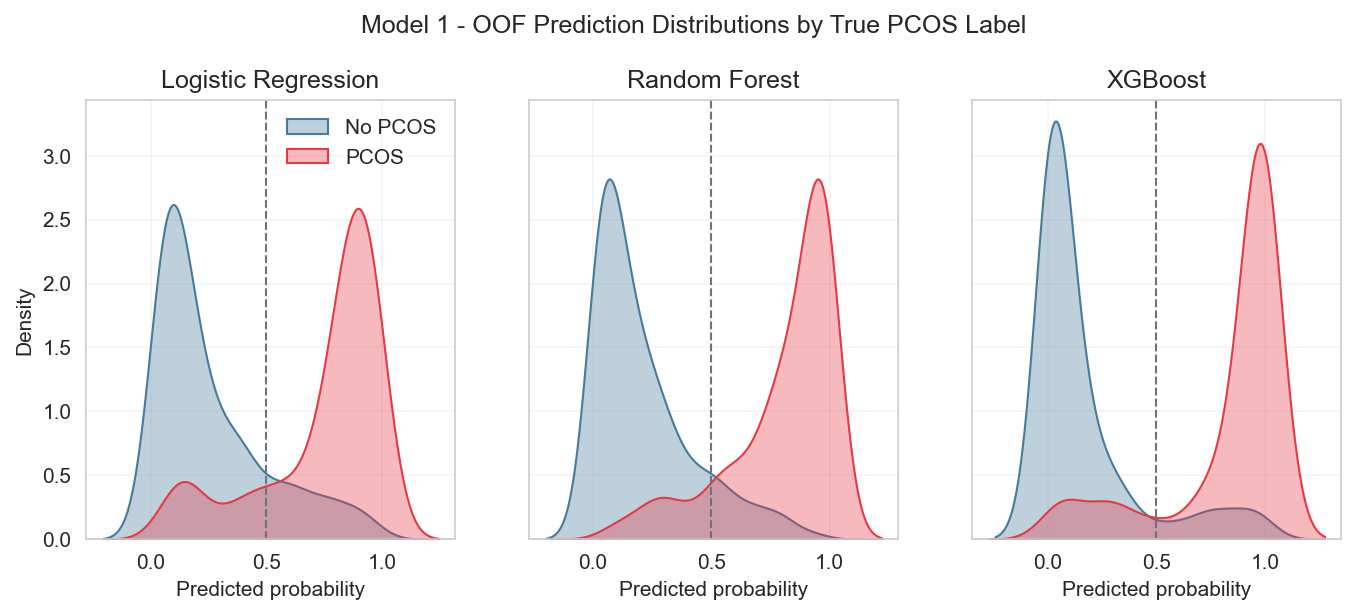

In [14]:
# Plotting the Model 1 OOF distributions is showing how the base learners score negative and positive cases before stacking.
fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.8), sharey=True)
probability_columns = ["LR_prob", "RF_prob", "XGB_prob"]
titles = ["Logistic Regression", "Random Forest", "XGBoost"]

for ax, column, title in zip(axes, probability_columns, titles):
    sns.kdeplot(
        data=oof1_df[oof1_df["true_label"] == 0],
        x=column,
        fill=True,
        alpha=0.35,
        color=COLORS["pcos_neg"],
        label="No PCOS",
        ax=ax,
    )
    sns.kdeplot(
        data=oof1_df[oof1_df["true_label"] == 1],
        x=column,
        fill=True,
        alpha=0.35,
        color=COLORS["pcos_pos"],
        label="PCOS",
        ax=ax,
    )
    ax.axvline(0.5, linestyle="--", color="#6B7280", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.20)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(handles[:2], labels[:2], frameon=False)

fig.suptitle("Model 1 - OOF Prediction Distributions by True PCOS Label", y=1.03)
output_path = IMAGE_DIR / "01_model1_oof_prediction_distributions.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


Model 1 demonstrates good class separation across all models, with XGBoost achieving the clearest distinction between PCOS and non-PCOS cases. However, compared to Model 2, there is slightly more overlap between classes, indicating that Model 2 generalizes better and produces more confident prediction

In [16]:
# Building the Model 1 test prediction matrix is using the saved full-training base models directly to create meta-features for the hold-out test set.
test_preds_1 = np.column_stack([
    lr1.predict_proba(X1_test)[:, 1],
    rf1.predict_proba(X1_test)[:, 1],
    xgb1.predict_proba(X1_test)[:, 1],
])

test_preds_1_df = pd.DataFrame(test_preds_1, columns=["LR_prob", "RF_prob", "XGB_prob"])

print("Model 1 test prediction matrix shape:", test_preds_1.shape)
print()
print(test_preds_1_df.head())


Model 1 test prediction matrix shape: (109, 3)

   LR_prob  RF_prob  XGB_prob
0   0.1636   0.2333    0.1690
1   0.0884   0.1733    0.1050
2   0.0546   0.0433    0.0087
3   0.7891   0.6633    0.7104
4   0.1558   0.2033    0.1205


## OOF Generation - Model 2

This section is generating out-of-fold probability predictions for the invasive benchmark model. The same leakage-safe logic is being used here so the meta-learner is trained on genuinely unseen base-learner outputs.


In [17]:
# Generating Model 2 OOF probabilities is creating the leakage-safe meta-learner training matrix for the invasive benchmark set.
base_learners_2 = [
    ("LR", lr2),
    ("RF", rf2),
    ("XGB", xgb2),
]

oof2, fill_counts2 = generate_oof_probabilities(base_learners_2, X2_train, y2_train, cv)

assert oof2.shape == (X2_train.shape[0], 3), f"Unexpected Model 2 OOF shape: {oof2.shape}"
assert np.all(fill_counts2 == 1), "Each Model 2 training row must be filled exactly once."

print()
print(f"OOF matrix shape : {oof2.shape}")
print(f"Fill-count check : {pd.Series(fill_counts2).value_counts().sort_index().to_dict()}")
print()
print("OOF matrix - first 5 rows:")
print(pd.DataFrame(oof2, columns=["LR_prob", "RF_prob", "XGB_prob"]).head())


Fold 1 / 10 complete
Fold 2 / 10 complete
Fold 3 / 10 complete
Fold 4 / 10 complete
Fold 5 / 10 complete
Fold 6 / 10 complete
Fold 7 / 10 complete
Fold 8 / 10 complete
Fold 9 / 10 complete
Fold 10 / 10 complete

OOF matrix shape : (582, 3)
Fill-count check : {1: 582}

OOF matrix - first 5 rows:
   LR_prob  RF_prob  XGB_prob
0   0.4305   0.3600    0.1650
1   0.2918   0.1467    0.0407
2   0.1139   0.0200    0.0017
3   0.5197   0.5833    0.5851
4   0.8011   0.8100    0.9442


In [18]:
# Saving the Model 2 OOF matrix is preserving the invasive stacking training inputs for later checks and reuse.
model2_oof_path = MODELS_DIR / "model2_oof_predictions.npy"
np.save(model2_oof_path, oof2)
print(f"Saved OOF predictions to: {model2_oof_path}")


Saved OOF predictions to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_oof_predictions.npy


In [19]:
# Printing Model 2 OOF statistics is showing how strongly the invasive base learners separate the two labels before stacking.
oof2_df = pd.DataFrame(oof2, columns=["LR_prob", "RF_prob", "XGB_prob"])
oof2_df["true_label"] = y2_train

print("OOF Prediction Statistics - Model 2")
print(oof2_df[["LR_prob", "RF_prob", "XGB_prob"]].describe().round(4))
print()
model2_oof_grouped = oof2_df.groupby("true_label")[["LR_prob", "RF_prob", "XGB_prob"]].mean().round(4)
print("Mean OOF probability by true label:")
print(model2_oof_grouped)


OOF Prediction Statistics - Model 2
       LR_prob  RF_prob  XGB_prob
count 582.0000 582.0000  582.0000
mean    0.4998   0.5135    0.5118
std     0.3182   0.3517    0.4357
min     0.0304   0.0067    0.0008
25%     0.1701   0.1433    0.0263
50%     0.5153   0.5250    0.5402
75%     0.8048   0.8667    0.9714
max     0.9982   1.0000    0.9995

Mean OOF probability by true label:
            LR_prob  RF_prob  XGB_prob
true_label                            
0            0.2642   0.2336    0.1674
1            0.7354   0.7935    0.8563


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\02_model2_oof_prediction_distributions.png


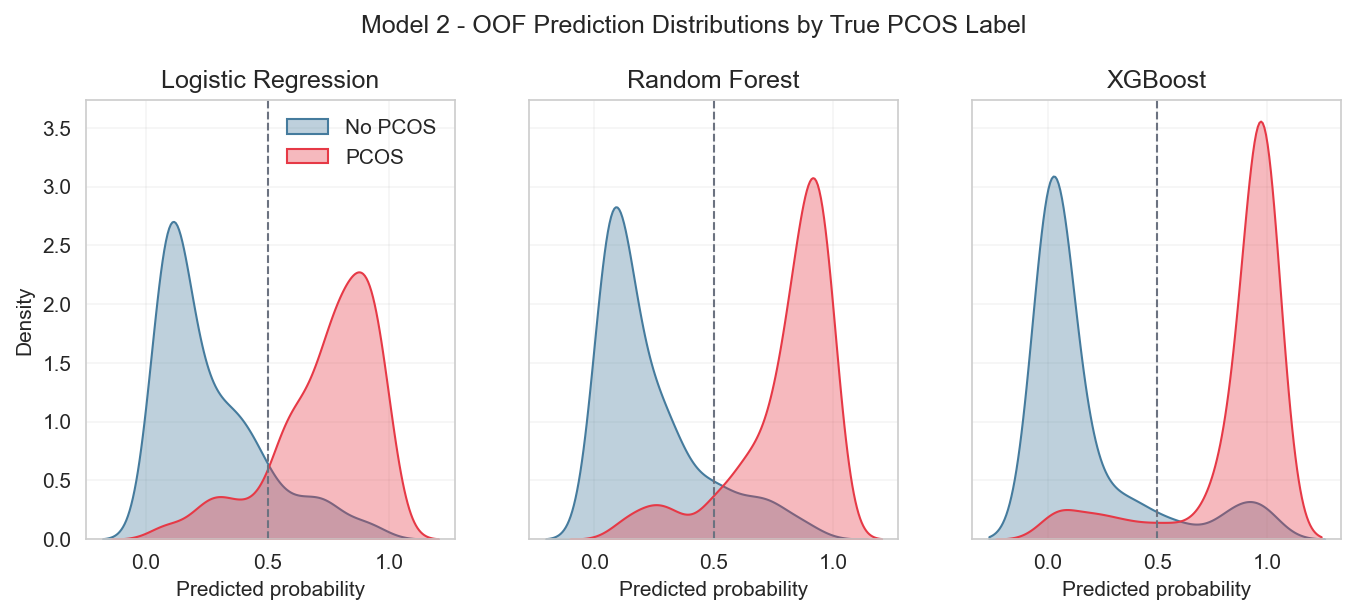

In [20]:
# Plotting the Model 2 OOF distributions is checking how cleanly the invasive base learners separate positive and negative cases before the meta-learner stage.
fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.8), sharey=True)
probability_columns = ["LR_prob", "RF_prob", "XGB_prob"]
titles = ["Logistic Regression", "Random Forest", "XGBoost"]

for ax, column, title in zip(axes, probability_columns, titles):
    sns.kdeplot(
        data=oof2_df[oof2_df["true_label"] == 0],
        x=column,
        fill=True,
        alpha=0.35,
        color=COLORS["pcos_neg"],
        label="No PCOS",
        ax=ax,
    )
    sns.kdeplot(
        data=oof2_df[oof2_df["true_label"] == 1],
        x=column,
        fill=True,
        alpha=0.35,
        color=COLORS["pcos_pos"],
        label="PCOS",
        ax=ax,
    )
    ax.axvline(0.5, linestyle="--", color="#6B7280", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.20)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(handles[:2], labels[:2], frameon=False)

fig.suptitle("Model 2 - OOF Prediction Distributions by True PCOS Label", y=1.03)
output_path = IMAGE_DIR / "02_model2_oof_prediction_distributions.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


XGBoost shows the best class separation with minimal overlap between PCOS and non-PCOS predictions, indicating superior discriminative performance. Logistic Regression exhibits significant overlap, suggesting weaker predictive confidence, while Random Forest performs moderately well but still shows some uncertainty in boundary regions.

In [22]:
# Building the Model 2 test prediction matrix is using the saved full-training invasive base models directly for the hold-out test set.
test_preds_2 = np.column_stack([
    lr2.predict_proba(X2_test)[:, 1],
    rf2.predict_proba(X2_test)[:, 1],
    xgb2.predict_proba(X2_test)[:, 1],
])

test_preds_2_df = pd.DataFrame(test_preds_2, columns=["LR_prob", "RF_prob", "XGB_prob"])

print("Model 2 test prediction matrix shape:", test_preds_2.shape)
print()
print(test_preds_2_df.head())


Model 2 test prediction matrix shape: (109, 3)

   LR_prob  RF_prob  XGB_prob
0   0.0827   0.1367    0.0485
1   0.7630   0.6267    0.8672
2   0.1708   0.5433    0.4780
3   0.9213   0.8400    0.9626
4   0.0991   0.1533    0.0073


## Section 3 - Model 1: Three Meta-Learner Variants

This section is training three different meta-learners on the Model 1 out-of-fold matrix. The base learners stay the same. Only the second-level combination rule changes.

The three meta-learner candidates are:

- Logistic Regression
- Random Forest
- XGBoost

The best performer by AUC and recall will be the Model 1 stacking candidate that moves forward to the later optimization notebook.


## Model 1: Meta-Learner - Logistic Regression

Logistic Regression is serving as the first meta-learner for Model 1. It is learning a simple weighted combination of the three base-learner probabilities. If this meta-learner wins, it means the base learners mostly need a clean linear weighting rather than a complex second-level rule.


In [23]:
# Training Model 1 with the Logistic Regression meta-learner is fitting the second-level model on the out-of-fold base predictions.
meta_lr1 = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
meta_lr1.fit(oof1, y1_train)
print("meta_lr1 trained successfully.")


meta_lr1 trained successfully.


In [24]:
# Evaluating the Logistic Regression meta-learner on the stacked test features is producing the final test-set metrics for this stacking variant.
stack_lr1_proba = meta_lr1.predict_proba(test_preds_1)[:, 1]
stack_lr1_pred = (stack_lr1_proba >= 0.5).astype(int)
results_stack_m1_lr = evaluate_model("Model 1 - Stack-LR", meta_lr1, test_preds_1, y1_test)

results_stack_m1_lr_df = pd.DataFrame([results_stack_m1_lr]).round(4)
print(results_stack_m1_lr_df.to_string(index=False))


             model  accuracy  precision  recall     f1    auc
Model 1 - Stack-LR    0.8440     0.7879  0.7222 0.7536 0.9113


In [25]:
# Writing the simple metric reading is making this stacking result easier to explain aloud.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_stack_m1_lr['accuracy']:.4f}**. This is the share of all test cases this stack model got right.",
    f"- Precision: **{results_stack_m1_lr['precision']:.4f}**. This shows how often a positive stack prediction was correct.",
    f"- Recall: **{results_stack_m1_lr['recall']:.4f}**. This shows how many true PCOS cases this stack model caught.",
    f"- F1 score: **{results_stack_m1_lr['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_stack_m1_lr['auc']:.4f}**. This shows how well this stack model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 1 with Logistic Regression as the meta-learner is catching about **{results_stack_m1_lr['recall'] * 100:.1f}%** of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8440**. This is the share of all test cases this stack model got right.
- Precision: **0.7879**. This shows how often a positive stack prediction was correct.
- Recall: **0.7222**. This shows how many true PCOS cases this stack model caught.
- F1 score: **0.7536**. This is the balance between precision and recall.
- AUC: **0.9113**. This shows how well this stack model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 1 with Logistic Regression as the meta-learner is catching about **72.2%** of PCOS-positive cases in the test set.

In [26]:
# Printing the confusion matrix table is showing the exact counts behind the heatmap for this stacking variant.
cm_stack_m1_lr = confusion_matrix(y1_test, stack_lr1_pred)
cm_stack_m1_lr_df = pd.DataFrame(
    cm_stack_m1_lr,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 1 Logistic Regression:")
print(cm_stack_m1_lr_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_stack_m1_lr[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_stack_m1_lr[1, 0]}")
print(f"False Positives (false alarms)      : {cm_stack_m1_lr[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_stack_m1_lr[0, 0]}")


Confusion Matrix - Model 1 Logistic Regression:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  66                7
Actual: PCOS                     10               26

True Positives  (caught PCOS cases) : 26
False Negatives (missed PCOS cases) : 10
False Positives (false alarms)      : 7
True Negatives  (correctly cleared) : 66


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\03_model1_stack_lr_confusion_matrix.png


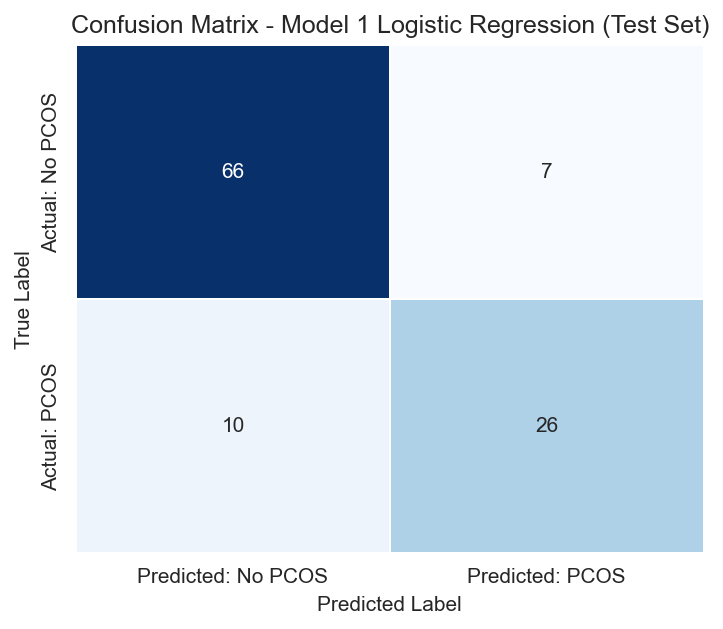

In [27]:
# Plotting the confusion matrix is turning the count table into a simple visual summary for this stacking model.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_stack_m1_lr_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 1 Logistic Regression (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "03_model1_stack_lr_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [28]:
# Writing the confusion-matrix insight is explaining the error pattern in plain language.
tp = int(cm_stack_m1_lr[1, 1])
fn = int(cm_stack_m1_lr[1, 0])
fp = int(cm_stack_m1_lr[0, 1])
tn = int(cm_stack_m1_lr[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the stack model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the stack model still missed.",
    f"- False positives: **{fp}**. These are false alarms where the stack model predicted PCOS but the case was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the stack model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 1 with Logistic Regression as the meta-learner, the most important number is the false-negative count of **{fn}**, because missed PCOS cases matter most in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **26**. These are PCOS cases the stack model caught correctly.
- False negatives: **10**. These are real PCOS cases the stack model still missed.
- False positives: **7**. These are false alarms where the stack model predicted PCOS but the case was negative.
- True negatives: **66**. These are non-PCOS cases the stack model cleared correctly.

**Simple meaning:** For Model 1 with Logistic Regression as the meta-learner, the most important number is the false-negative count of **10**, because missed PCOS cases matter most in a screening study.

In [29]:
# Saving the fitted meta-learner is keeping this stacking variant available for the optimization notebook.
model_path = MODELS_DIR / "model1_stack_lr_meta.pkl"
joblib.dump(meta_lr1, model_path)
print(f"Saved model to: {model_path}")


Saved model to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_stack_lr_meta.pkl


## Model 1: Meta-Learner - Random Forest

Random Forest is serving as the second meta-learner for Model 1. It is checking whether a non-linear rule can combine the three base-learner probabilities better than a straight weighted average. If this meta-learner wins, it suggests the base models are making useful predictions in different parts of the patient profile space.


In [30]:
# Training Model 1 with the Random Forest meta-learner is fitting the second-level model on the out-of-fold base predictions.
meta_rf1 = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)
meta_rf1.fit(oof1, y1_train)
print("meta_rf1 trained successfully.")


meta_rf1 trained successfully.


In [31]:
# Evaluating the Random Forest meta-learner on the stacked test features is producing the final test-set metrics for this stacking variant.
stack_rf1_proba = meta_rf1.predict_proba(test_preds_1)[:, 1]
stack_rf1_pred = (stack_rf1_proba >= 0.5).astype(int)
results_stack_m1_rf = evaluate_model("Model 1 - Stack-RF", meta_rf1, test_preds_1, y1_test)

results_stack_m1_rf_df = pd.DataFrame([results_stack_m1_rf]).round(4)
print(results_stack_m1_rf_df.to_string(index=False))


             model  accuracy  precision  recall     f1    auc
Model 1 - Stack-RF    0.8440     0.8276  0.6667 0.7385 0.8777


In [32]:
# Writing the simple metric reading is making this stacking result easier to explain aloud.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_stack_m1_rf['accuracy']:.4f}**. This is the share of all test cases this stack model got right.",
    f"- Precision: **{results_stack_m1_rf['precision']:.4f}**. This shows how often a positive stack prediction was correct.",
    f"- Recall: **{results_stack_m1_rf['recall']:.4f}**. This shows how many true PCOS cases this stack model caught.",
    f"- F1 score: **{results_stack_m1_rf['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_stack_m1_rf['auc']:.4f}**. This shows how well this stack model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 1 with Random Forest as the meta-learner is catching about **{results_stack_m1_rf['recall'] * 100:.1f}%** of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8440**. This is the share of all test cases this stack model got right.
- Precision: **0.8276**. This shows how often a positive stack prediction was correct.
- Recall: **0.6667**. This shows how many true PCOS cases this stack model caught.
- F1 score: **0.7385**. This is the balance between precision and recall.
- AUC: **0.8777**. This shows how well this stack model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 1 with Random Forest as the meta-learner is catching about **66.7%** of PCOS-positive cases in the test set.

In [33]:
# Printing the confusion matrix table is showing the exact counts behind the heatmap for this stacking variant.
cm_stack_m1_rf = confusion_matrix(y1_test, stack_rf1_pred)
cm_stack_m1_rf_df = pd.DataFrame(
    cm_stack_m1_rf,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 1 Random Forest:")
print(cm_stack_m1_rf_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_stack_m1_rf[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_stack_m1_rf[1, 0]}")
print(f"False Positives (false alarms)      : {cm_stack_m1_rf[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_stack_m1_rf[0, 0]}")


Confusion Matrix - Model 1 Random Forest:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  68                5
Actual: PCOS                     12               24

True Positives  (caught PCOS cases) : 24
False Negatives (missed PCOS cases) : 12
False Positives (false alarms)      : 5
True Negatives  (correctly cleared) : 68


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\04_model1_stack_rf_confusion_matrix.png


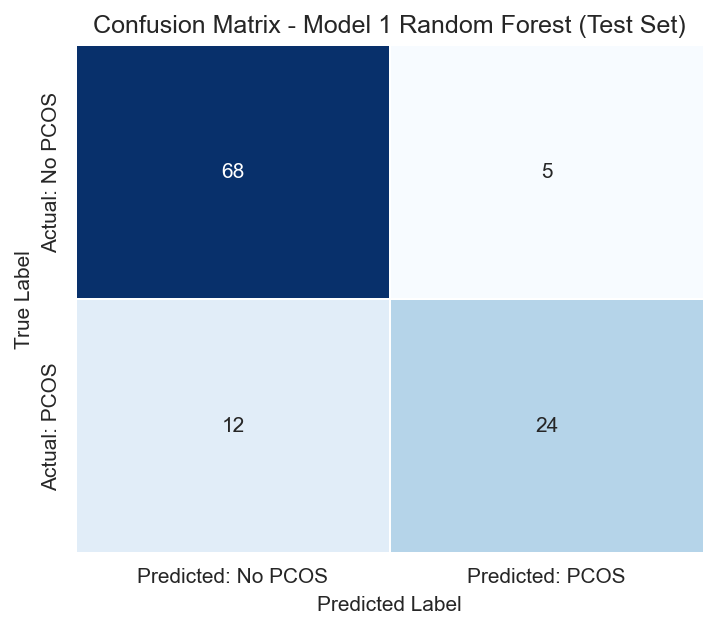

In [34]:
# Plotting the confusion matrix is turning the count table into a simple visual summary for this stacking model.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_stack_m1_rf_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 1 Random Forest (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "04_model1_stack_rf_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [35]:
# Writing the confusion-matrix insight is explaining the error pattern in plain language.
tp = int(cm_stack_m1_rf[1, 1])
fn = int(cm_stack_m1_rf[1, 0])
fp = int(cm_stack_m1_rf[0, 1])
tn = int(cm_stack_m1_rf[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the stack model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the stack model still missed.",
    f"- False positives: **{fp}**. These are false alarms where the stack model predicted PCOS but the case was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the stack model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 1 with Random Forest as the meta-learner, the most important number is the false-negative count of **{fn}**, because missed PCOS cases matter most in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **24**. These are PCOS cases the stack model caught correctly.
- False negatives: **12**. These are real PCOS cases the stack model still missed.
- False positives: **5**. These are false alarms where the stack model predicted PCOS but the case was negative.
- True negatives: **68**. These are non-PCOS cases the stack model cleared correctly.

**Simple meaning:** For Model 1 with Random Forest as the meta-learner, the most important number is the false-negative count of **12**, because missed PCOS cases matter most in a screening study.

In [36]:
# Saving the fitted meta-learner is keeping this stacking variant available for the optimization notebook.
model_path = MODELS_DIR / "model1_stack_rf_meta.pkl"
joblib.dump(meta_rf1, model_path)
print(f"Saved model to: {model_path}")


Saved model to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_stack_rf_meta.pkl


## Model 1: Meta-Learner - XGBoost

XGBoost is serving as the third meta-learner for Model 1. It is learning a boosted non-linear combination of the three base-learner probabilities. If this version performs best, it means the best final decision rule is itself boosted and non-linear.


In [37]:
# Training Model 1 with the XGBoost meta-learner is fitting the second-level model on the out-of-fold base predictions.
meta_xgb1 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
meta_xgb1.fit(oof1, y1_train)
print("meta_xgb1 trained successfully.")


meta_xgb1 trained successfully.


In [38]:
# Evaluating the XGBoost meta-learner on the stacked test features is producing the final test-set metrics for this stacking variant.
stack_xgb1_proba = meta_xgb1.predict_proba(test_preds_1)[:, 1]
stack_xgb1_pred = (stack_xgb1_proba >= 0.5).astype(int)
results_stack_m1_xgb = evaluate_model("Model 1 - Stack-XGB", meta_xgb1, test_preds_1, y1_test)

results_stack_m1_xgb_df = pd.DataFrame([results_stack_m1_xgb]).round(4)
print(results_stack_m1_xgb_df.to_string(index=False))


              model  accuracy  precision  recall     f1    auc
Model 1 - Stack-XGB    0.8257     0.8148  0.6111 0.6984 0.8809


In [39]:
# Writing the simple metric reading is making this stacking result easier to explain aloud.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_stack_m1_xgb['accuracy']:.4f}**. This is the share of all test cases this stack model got right.",
    f"- Precision: **{results_stack_m1_xgb['precision']:.4f}**. This shows how often a positive stack prediction was correct.",
    f"- Recall: **{results_stack_m1_xgb['recall']:.4f}**. This shows how many true PCOS cases this stack model caught.",
    f"- F1 score: **{results_stack_m1_xgb['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_stack_m1_xgb['auc']:.4f}**. This shows how well this stack model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 1 with XGBoost as the meta-learner is catching about **{results_stack_m1_xgb['recall'] * 100:.1f}%** of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8257**. This is the share of all test cases this stack model got right.
- Precision: **0.8148**. This shows how often a positive stack prediction was correct.
- Recall: **0.6111**. This shows how many true PCOS cases this stack model caught.
- F1 score: **0.6984**. This is the balance between precision and recall.
- AUC: **0.8809**. This shows how well this stack model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 1 with XGBoost as the meta-learner is catching about **61.1%** of PCOS-positive cases in the test set.

In [40]:
# Printing the confusion matrix table is showing the exact counts behind the heatmap for this stacking variant.
cm_stack_m1_xgb = confusion_matrix(y1_test, stack_xgb1_pred)
cm_stack_m1_xgb_df = pd.DataFrame(
    cm_stack_m1_xgb,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 1 XGBoost:")
print(cm_stack_m1_xgb_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_stack_m1_xgb[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_stack_m1_xgb[1, 0]}")
print(f"False Positives (false alarms)      : {cm_stack_m1_xgb[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_stack_m1_xgb[0, 0]}")


Confusion Matrix - Model 1 XGBoost:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  68                5
Actual: PCOS                     14               22

True Positives  (caught PCOS cases) : 22
False Negatives (missed PCOS cases) : 14
False Positives (false alarms)      : 5
True Negatives  (correctly cleared) : 68


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\05_model1_stack_xgb_confusion_matrix.png


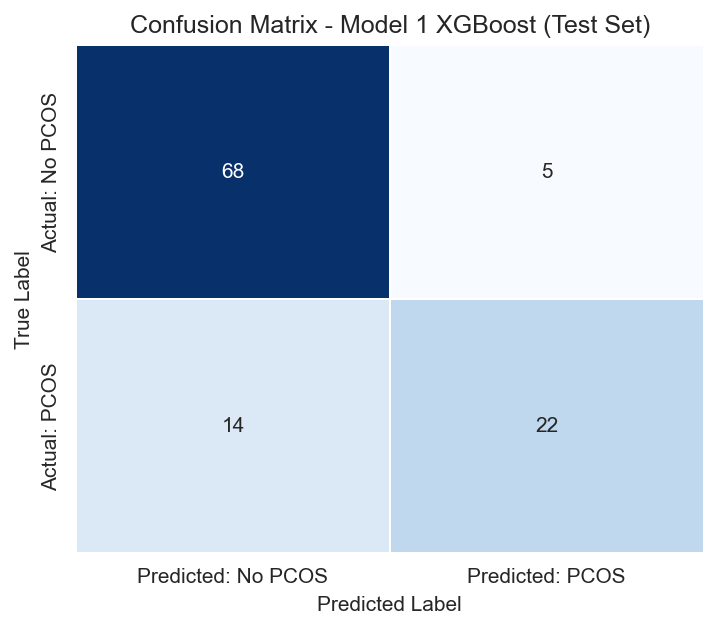

In [41]:
# Plotting the confusion matrix is turning the count table into a simple visual summary for this stacking model.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_stack_m1_xgb_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 1 XGBoost (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "05_model1_stack_xgb_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [42]:
# Writing the confusion-matrix insight is explaining the error pattern in plain language.
tp = int(cm_stack_m1_xgb[1, 1])
fn = int(cm_stack_m1_xgb[1, 0])
fp = int(cm_stack_m1_xgb[0, 1])
tn = int(cm_stack_m1_xgb[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the stack model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the stack model still missed.",
    f"- False positives: **{fp}**. These are false alarms where the stack model predicted PCOS but the case was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the stack model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 1 with XGBoost as the meta-learner, the most important number is the false-negative count of **{fn}**, because missed PCOS cases matter most in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **22**. These are PCOS cases the stack model caught correctly.
- False negatives: **14**. These are real PCOS cases the stack model still missed.
- False positives: **5**. These are false alarms where the stack model predicted PCOS but the case was negative.
- True negatives: **68**. These are non-PCOS cases the stack model cleared correctly.

**Simple meaning:** For Model 1 with XGBoost as the meta-learner, the most important number is the false-negative count of **14**, because missed PCOS cases matter most in a screening study.

In [43]:
# Saving the fitted meta-learner is keeping this stacking variant available for the optimization notebook.
model_path = MODELS_DIR / "model1_stack_xgb_meta.pkl"
joblib.dump(meta_xgb1, model_path)
print(f"Saved model to: {model_path}")


Saved model to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_stack_xgb_meta.pkl


## Model 1: Stacking Results Summary

This section is comparing the three meta-learner options inside Model 1. The goal is finding the best stacking rule for this model set before building the master comparison table.


## Section 4 - Model 2: Three Meta-Learner Variants

This section is repeating the same stacking design for the invasive benchmark model. The question here is slightly different: which second-level combination rule gets the most value from the hormonal and ultrasound base-learner outputs?


## Model 2: Meta-Learner - Logistic Regression

Logistic Regression is serving as the first meta-learner for Model 2. It is checking whether the invasive base-learner probabilities only need a simple linear combination. This helps show whether the benchmark signal is already very clean.


In [44]:
# Training Model 2 with the Logistic Regression meta-learner is fitting the second-level model on the out-of-fold base predictions.
meta_lr2 = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
meta_lr2.fit(oof2, y2_train)
print("meta_lr2 trained successfully.")


meta_lr2 trained successfully.


In [45]:
# Evaluating the Logistic Regression meta-learner on the stacked test features is producing the final test-set metrics for this stacking variant.
stack_lr2_proba = meta_lr2.predict_proba(test_preds_2)[:, 1]
stack_lr2_pred = (stack_lr2_proba >= 0.5).astype(int)
results_stack_m2_lr = evaluate_model("Model 2 - Stack-LR", meta_lr2, test_preds_2, y2_test)

results_stack_m2_lr_df = pd.DataFrame([results_stack_m2_lr]).round(4)
print(results_stack_m2_lr_df.to_string(index=False))


             model  accuracy  precision  recall     f1    auc
Model 2 - Stack-LR    0.8899     0.8529  0.8056 0.8286 0.9037


In [46]:
# Writing the simple metric reading is making this stacking result easier to explain aloud.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_stack_m2_lr['accuracy']:.4f}**. This is the share of all test cases this stack model got right.",
    f"- Precision: **{results_stack_m2_lr['precision']:.4f}**. This shows how often a positive stack prediction was correct.",
    f"- Recall: **{results_stack_m2_lr['recall']:.4f}**. This shows how many true PCOS cases this stack model caught.",
    f"- F1 score: **{results_stack_m2_lr['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_stack_m2_lr['auc']:.4f}**. This shows how well this stack model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 2 with Logistic Regression as the meta-learner is catching about **{results_stack_m2_lr['recall'] * 100:.1f}%** of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8899**. This is the share of all test cases this stack model got right.
- Precision: **0.8529**. This shows how often a positive stack prediction was correct.
- Recall: **0.8056**. This shows how many true PCOS cases this stack model caught.
- F1 score: **0.8286**. This is the balance between precision and recall.
- AUC: **0.9037**. This shows how well this stack model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 2 with Logistic Regression as the meta-learner is catching about **80.6%** of PCOS-positive cases in the test set.

In [47]:
# Printing the confusion matrix table is showing the exact counts behind the heatmap for this stacking variant.
cm_stack_m2_lr = confusion_matrix(y2_test, stack_lr2_pred)
cm_stack_m2_lr_df = pd.DataFrame(
    cm_stack_m2_lr,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 2 Logistic Regression:")
print(cm_stack_m2_lr_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_stack_m2_lr[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_stack_m2_lr[1, 0]}")
print(f"False Positives (false alarms)      : {cm_stack_m2_lr[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_stack_m2_lr[0, 0]}")


Confusion Matrix - Model 2 Logistic Regression:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  68                5
Actual: PCOS                      7               29

True Positives  (caught PCOS cases) : 29
False Negatives (missed PCOS cases) : 7
False Positives (false alarms)      : 5
True Negatives  (correctly cleared) : 68


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\06_model2_stack_lr_confusion_matrix.png


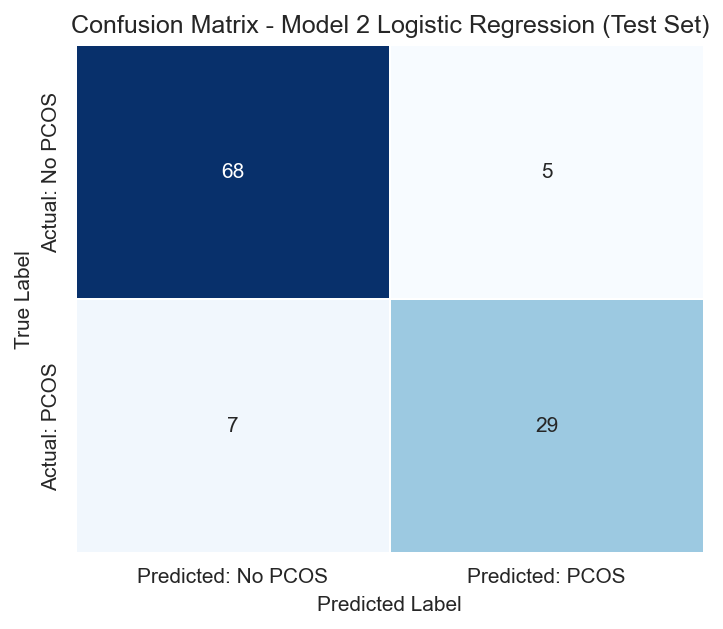

In [48]:
# Plotting the confusion matrix is turning the count table into a simple visual summary for this stacking model.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_stack_m2_lr_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 2 Logistic Regression (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "06_model2_stack_lr_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [49]:
# Writing the confusion-matrix insight is explaining the error pattern in plain language.
tp = int(cm_stack_m2_lr[1, 1])
fn = int(cm_stack_m2_lr[1, 0])
fp = int(cm_stack_m2_lr[0, 1])
tn = int(cm_stack_m2_lr[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the stack model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the stack model still missed.",
    f"- False positives: **{fp}**. These are false alarms where the stack model predicted PCOS but the case was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the stack model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 2 with Logistic Regression as the meta-learner, the most important number is the false-negative count of **{fn}**, because missed PCOS cases matter most in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **29**. These are PCOS cases the stack model caught correctly.
- False negatives: **7**. These are real PCOS cases the stack model still missed.
- False positives: **5**. These are false alarms where the stack model predicted PCOS but the case was negative.
- True negatives: **68**. These are non-PCOS cases the stack model cleared correctly.

**Simple meaning:** For Model 2 with Logistic Regression as the meta-learner, the most important number is the false-negative count of **7**, because missed PCOS cases matter most in a screening study.

In [50]:
# Saving the fitted meta-learner is keeping this stacking variant available for the optimization notebook.
model_path = MODELS_DIR / "model2_stack_lr_meta.pkl"
joblib.dump(meta_lr2, model_path)
print(f"Saved model to: {model_path}")


Saved model to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_stack_lr_meta.pkl


## Model 2: Meta-Learner - Random Forest

Random Forest is serving as the second meta-learner for Model 2. It is checking whether the invasive benchmark benefits from a tree-based combination rule at the stacking level. This matters because the hormonal and ultrasound signals may interact in a non-linear way even after the base models have already learned from them.


In [51]:
# Training Model 2 with the Random Forest meta-learner is fitting the second-level model on the out-of-fold base predictions.
meta_rf2 = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)
meta_rf2.fit(oof2, y2_train)
print("meta_rf2 trained successfully.")


meta_rf2 trained successfully.


In [52]:
# Evaluating the Random Forest meta-learner on the stacked test features is producing the final test-set metrics for this stacking variant.
stack_rf2_proba = meta_rf2.predict_proba(test_preds_2)[:, 1]
stack_rf2_pred = (stack_rf2_proba >= 0.5).astype(int)
results_stack_m2_rf = evaluate_model("Model 2 - Stack-RF", meta_rf2, test_preds_2, y2_test)

results_stack_m2_rf_df = pd.DataFrame([results_stack_m2_rf]).round(4)
print(results_stack_m2_rf_df.to_string(index=False))


             model  accuracy  precision  recall     f1    auc
Model 2 - Stack-RF    0.8257     0.7742  0.6667 0.7164 0.8969


In [53]:
# Writing the simple metric reading is making this stacking result easier to explain aloud.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_stack_m2_rf['accuracy']:.4f}**. This is the share of all test cases this stack model got right.",
    f"- Precision: **{results_stack_m2_rf['precision']:.4f}**. This shows how often a positive stack prediction was correct.",
    f"- Recall: **{results_stack_m2_rf['recall']:.4f}**. This shows how many true PCOS cases this stack model caught.",
    f"- F1 score: **{results_stack_m2_rf['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_stack_m2_rf['auc']:.4f}**. This shows how well this stack model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 2 with Random Forest as the meta-learner is catching about **{results_stack_m2_rf['recall'] * 100:.1f}%** of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8257**. This is the share of all test cases this stack model got right.
- Precision: **0.7742**. This shows how often a positive stack prediction was correct.
- Recall: **0.6667**. This shows how many true PCOS cases this stack model caught.
- F1 score: **0.7164**. This is the balance between precision and recall.
- AUC: **0.8969**. This shows how well this stack model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 2 with Random Forest as the meta-learner is catching about **66.7%** of PCOS-positive cases in the test set.

In [54]:
# Printing the confusion matrix table is showing the exact counts behind the heatmap for this stacking variant.
cm_stack_m2_rf = confusion_matrix(y2_test, stack_rf2_pred)
cm_stack_m2_rf_df = pd.DataFrame(
    cm_stack_m2_rf,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 2 Random Forest:")
print(cm_stack_m2_rf_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_stack_m2_rf[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_stack_m2_rf[1, 0]}")
print(f"False Positives (false alarms)      : {cm_stack_m2_rf[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_stack_m2_rf[0, 0]}")


Confusion Matrix - Model 2 Random Forest:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  66                7
Actual: PCOS                     11               25

True Positives  (caught PCOS cases) : 25
False Negatives (missed PCOS cases) : 11
False Positives (false alarms)      : 7
True Negatives  (correctly cleared) : 66


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\07_model2_stack_rf_confusion_matrix.png


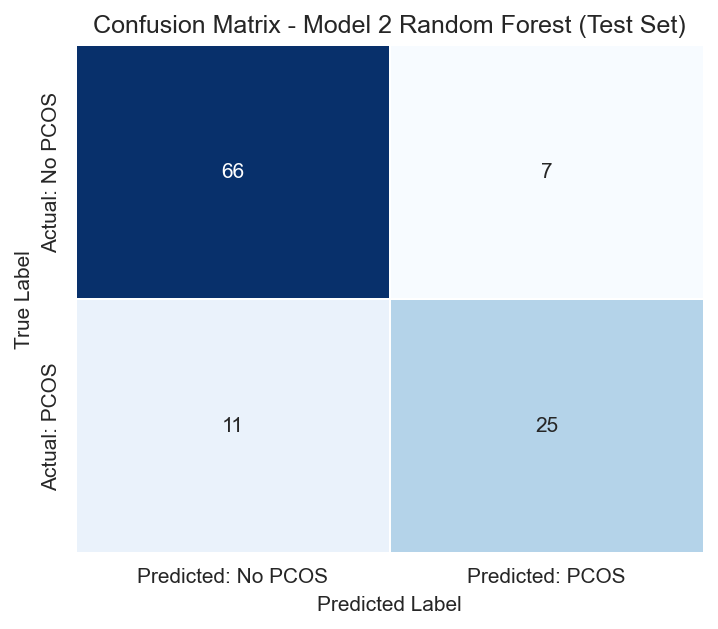

In [55]:
# Plotting the confusion matrix is turning the count table into a simple visual summary for this stacking model.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_stack_m2_rf_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 2 Random Forest (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "07_model2_stack_rf_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [56]:
# Writing the confusion-matrix insight is explaining the error pattern in plain language.
tp = int(cm_stack_m2_rf[1, 1])
fn = int(cm_stack_m2_rf[1, 0])
fp = int(cm_stack_m2_rf[0, 1])
tn = int(cm_stack_m2_rf[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the stack model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the stack model still missed.",
    f"- False positives: **{fp}**. These are false alarms where the stack model predicted PCOS but the case was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the stack model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 2 with Random Forest as the meta-learner, the most important number is the false-negative count of **{fn}**, because missed PCOS cases matter most in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **25**. These are PCOS cases the stack model caught correctly.
- False negatives: **11**. These are real PCOS cases the stack model still missed.
- False positives: **7**. These are false alarms where the stack model predicted PCOS but the case was negative.
- True negatives: **66**. These are non-PCOS cases the stack model cleared correctly.

**Simple meaning:** For Model 2 with Random Forest as the meta-learner, the most important number is the false-negative count of **11**, because missed PCOS cases matter most in a screening study.

In [57]:
# Saving the fitted meta-learner is keeping this stacking variant available for the optimization notebook.
model_path = MODELS_DIR / "model2_stack_rf_meta.pkl"
joblib.dump(meta_rf2, model_path)
print(f"Saved model to: {model_path}")


Saved model to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_stack_rf_meta.pkl


## Model 2: Meta-Learner - XGBoost

XGBoost is serving as the third meta-learner for Model 2. It is testing whether a boosted second-level model can get the most value from the invasive base-learner outputs. If it performs best, it suggests the strongest final combination rule is still boosted and non-linear even after the first layer.


In [58]:
# Training Model 2 with the XGBoost meta-learner is fitting the second-level model on the out-of-fold base predictions.
meta_xgb2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
meta_xgb2.fit(oof2, y2_train)
print("meta_xgb2 trained successfully.")


meta_xgb2 trained successfully.


In [59]:
# Evaluating the XGBoost meta-learner on the stacked test features is producing the final test-set metrics for this stacking variant.
stack_xgb2_proba = meta_xgb2.predict_proba(test_preds_2)[:, 1]
stack_xgb2_pred = (stack_xgb2_proba >= 0.5).astype(int)
results_stack_m2_xgb = evaluate_model("Model 2 - Stack-XGB", meta_xgb2, test_preds_2, y2_test)

results_stack_m2_xgb_df = pd.DataFrame([results_stack_m2_xgb]).round(4)
print(results_stack_m2_xgb_df.to_string(index=False))


              model  accuracy  precision  recall     f1    auc
Model 2 - Stack-XGB    0.8807     0.8710  0.7500 0.8060 0.8874


In [60]:
# Writing the simple metric reading is making this stacking result easier to explain aloud.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_stack_m2_xgb['accuracy']:.4f}**. This is the share of all test cases this stack model got right.",
    f"- Precision: **{results_stack_m2_xgb['precision']:.4f}**. This shows how often a positive stack prediction was correct.",
    f"- Recall: **{results_stack_m2_xgb['recall']:.4f}**. This shows how many true PCOS cases this stack model caught.",
    f"- F1 score: **{results_stack_m2_xgb['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_stack_m2_xgb['auc']:.4f}**. This shows how well this stack model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 2 with XGBoost as the meta-learner is catching about **{results_stack_m2_xgb['recall'] * 100:.1f}%** of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8807**. This is the share of all test cases this stack model got right.
- Precision: **0.8710**. This shows how often a positive stack prediction was correct.
- Recall: **0.7500**. This shows how many true PCOS cases this stack model caught.
- F1 score: **0.8060**. This is the balance between precision and recall.
- AUC: **0.8874**. This shows how well this stack model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 2 with XGBoost as the meta-learner is catching about **75.0%** of PCOS-positive cases in the test set.

In [61]:
# Printing the confusion matrix table is showing the exact counts behind the heatmap for this stacking variant.
cm_stack_m2_xgb = confusion_matrix(y2_test, stack_xgb2_pred)
cm_stack_m2_xgb_df = pd.DataFrame(
    cm_stack_m2_xgb,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 2 XGBoost:")
print(cm_stack_m2_xgb_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_stack_m2_xgb[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_stack_m2_xgb[1, 0]}")
print(f"False Positives (false alarms)      : {cm_stack_m2_xgb[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_stack_m2_xgb[0, 0]}")


Confusion Matrix - Model 2 XGBoost:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  69                4
Actual: PCOS                      9               27

True Positives  (caught PCOS cases) : 27
False Negatives (missed PCOS cases) : 9
False Positives (false alarms)      : 4
True Negatives  (correctly cleared) : 69


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\08_model2_stack_xgb_confusion_matrix.png


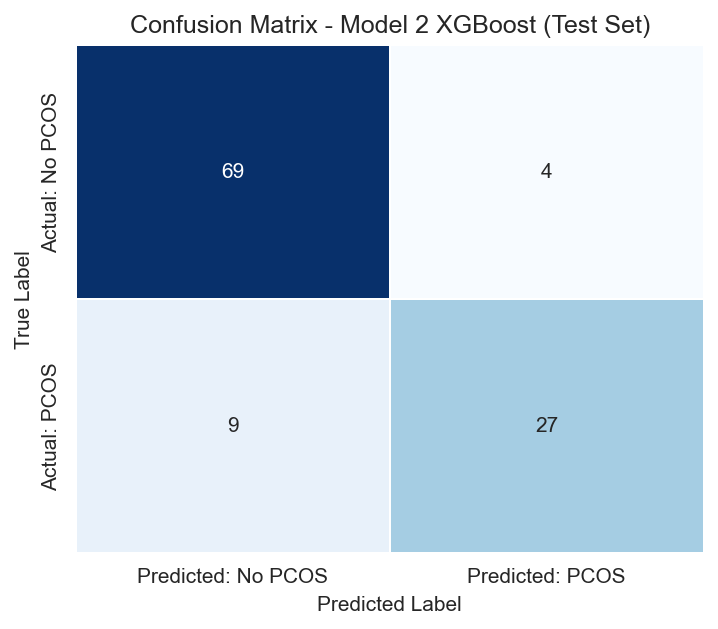

In [62]:
# Plotting the confusion matrix is turning the count table into a simple visual summary for this stacking model.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_stack_m2_xgb_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 2 XGBoost (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "08_model2_stack_xgb_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [63]:
# Writing the confusion-matrix insight is explaining the error pattern in plain language.
tp = int(cm_stack_m2_xgb[1, 1])
fn = int(cm_stack_m2_xgb[1, 0])
fp = int(cm_stack_m2_xgb[0, 1])
tn = int(cm_stack_m2_xgb[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the stack model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the stack model still missed.",
    f"- False positives: **{fp}**. These are false alarms where the stack model predicted PCOS but the case was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the stack model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 2 with XGBoost as the meta-learner, the most important number is the false-negative count of **{fn}**, because missed PCOS cases matter most in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **27**. These are PCOS cases the stack model caught correctly.
- False negatives: **9**. These are real PCOS cases the stack model still missed.
- False positives: **4**. These are false alarms where the stack model predicted PCOS but the case was negative.
- True negatives: **69**. These are non-PCOS cases the stack model cleared correctly.

**Simple meaning:** For Model 2 with XGBoost as the meta-learner, the most important number is the false-negative count of **9**, because missed PCOS cases matter most in a screening study.

In [64]:
# Saving the fitted meta-learner is keeping this stacking variant available for the optimization notebook.
model_path = MODELS_DIR / "model2_stack_xgb_meta.pkl"
joblib.dump(meta_xgb2, model_path)
print(f"Saved model to: {model_path}")


Saved model to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_stack_xgb_meta.pkl


## Model 2: Stacking Results Summary

This section is comparing the three meta-learner options inside Model 2. The goal is finding the best stacking rule for this model set before building the master comparison table.


## Section 5 - Master Stacking Comparison

This section is combining the six individual Notebook 08 results with the six new stacking results. This is giving the full performance picture before the later optimization stage.


In [65]:
# Building the full master table is combining all individual and stacking results into one comparison table.
individual = prev_results.copy()
individual["approach"] = "Individual"

stacking_rows = pd.DataFrame([
    results_stack_m1_lr,
    results_stack_m1_rf,
    results_stack_m1_xgb,
    results_stack_m2_lr,
    results_stack_m2_rf,
    results_stack_m2_xgb,
])
stacking_rows["approach"] = "Stacking"
stacking_rows["model_set"] = ["Model 1", "Model 1", "Model 1", "Model 2", "Model 2", "Model 2"]
stacking_rows["algorithm"] = ["Stack-LR", "Stack-RF", "Stack-XGB", "Stack-LR", "Stack-RF", "Stack-XGB"]

master = pd.concat([individual, stacking_rows], ignore_index=True).round(4)

print("MASTER RESULTS TABLE - Individual + Stacking (All Models)")
print("=" * 84)
print(master.to_string(index=False))


MASTER RESULTS TABLE - Individual + Stacking (All Models)
              model  accuracy  precision  recall     f1    auc model_set algorithm   approach
       Model 1 - LR    0.8349     0.7368  0.7778 0.7568 0.8839   Model 1        LR Individual
       Model 1 - RF    0.8532     0.8125  0.7222 0.7647 0.9098   Model 1        RF Individual
      Model 1 - XGB    0.8716     0.8438  0.7500 0.7941 0.9026   Model 1       XGB Individual
       Model 2 - LR    0.8349     0.7143  0.8333 0.7692 0.8988   Model 2        LR Individual
       Model 2 - RF    0.8349     0.7500  0.7500 0.7500 0.8955   Model 2        RF Individual
      Model 2 - XGB    0.8624     0.8000  0.7778 0.7887 0.9037   Model 2       XGB Individual
 Model 1 - Stack-LR    0.8440     0.7879  0.7222 0.7536 0.9113   Model 1  Stack-LR   Stacking
 Model 1 - Stack-RF    0.8440     0.8276  0.6667 0.7385 0.8777   Model 1  Stack-RF   Stacking
Model 1 - Stack-XGB    0.8257     0.8148  0.6111 0.6984 0.8809   Model 1 Stack-XGB   Stacking
 M

In [66]:
# Saving the complete master results table is preserving the full comparison for later notebooks and reporting.
master_results_path = DATA_DIR / "master_results_all_models.csv"
master.to_csv(master_results_path, index=False)
print(f"Saved master results to: {master_results_path}")


Saved master results to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\master_results_all_models.csv


In [67]:
# Saving the stacking-only results table is preserving the six new stack-model rows separately.
stacking_results_path = DATA_DIR / "stacking_results.csv"
stacking_rows.to_csv(stacking_results_path, index=False)
print(f"Saved stacking results to: {stacking_results_path}")


Saved stacking results to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\stacking_results.csv


In [68]:
# Printing the full heatmap input table is documenting the exact values before plotting the master comparison.
heatmap_df = master.set_index("model")[["accuracy", "precision", "recall", "f1", "auc"]]
print(heatmap_df.round(4).to_string())


                     accuracy  precision  recall     f1    auc
model                                                         
Model 1 - LR           0.8349     0.7368  0.7778 0.7568 0.8839
Model 1 - RF           0.8532     0.8125  0.7222 0.7647 0.9098
Model 1 - XGB          0.8716     0.8438  0.7500 0.7941 0.9026
Model 2 - LR           0.8349     0.7143  0.8333 0.7692 0.8988
Model 2 - RF           0.8349     0.7500  0.7500 0.7500 0.8955
Model 2 - XGB          0.8624     0.8000  0.7778 0.7887 0.9037
Model 1 - Stack-LR     0.8440     0.7879  0.7222 0.7536 0.9113
Model 1 - Stack-RF     0.8440     0.8276  0.6667 0.7385 0.8777
Model 1 - Stack-XGB    0.8257     0.8148  0.6111 0.6984 0.8809
Model 2 - Stack-LR     0.8899     0.8529  0.8056 0.8286 0.9037
Model 2 - Stack-RF     0.8257     0.7742  0.6667 0.7164 0.8969
Model 2 - Stack-XGB    0.8807     0.8710  0.7500 0.8060 0.8874


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\13_master_stacking_heatmap.png


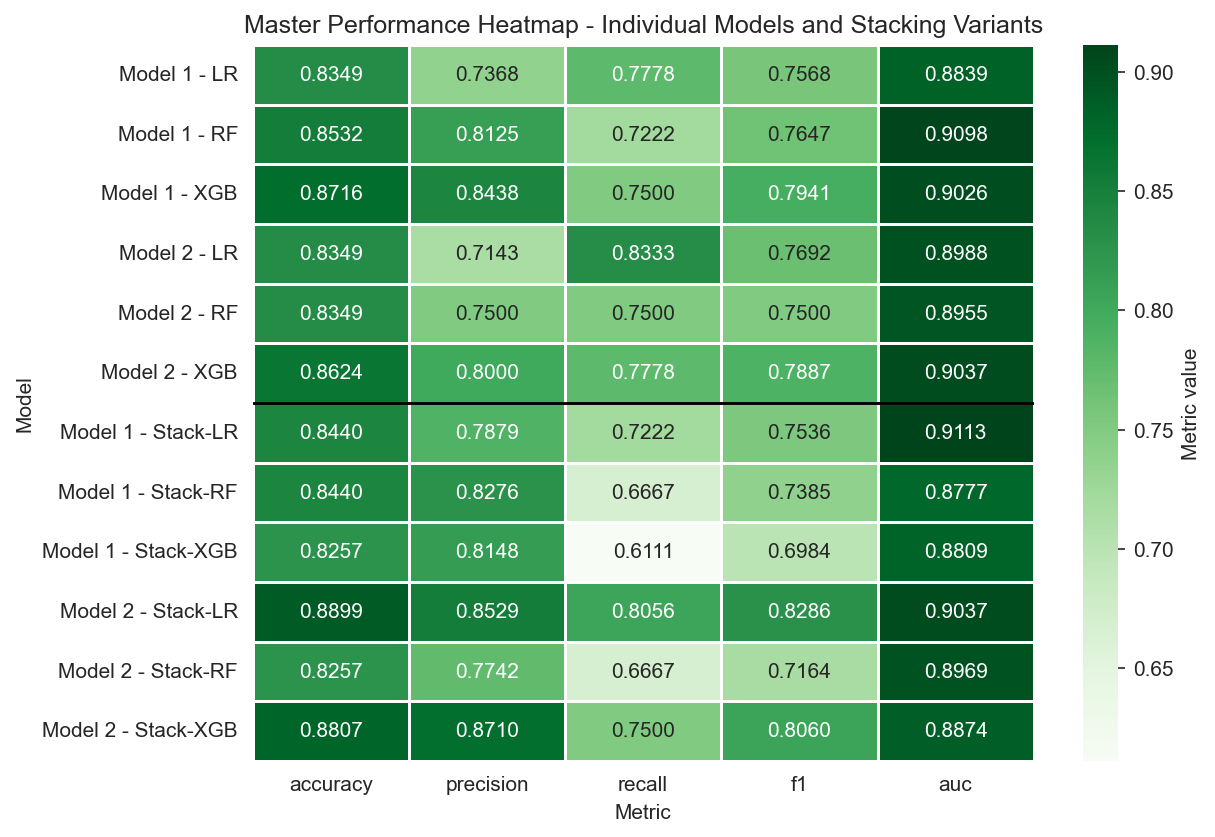

In [69]:
# Creating the master heatmap is showing the full performance picture before optimization.
fig, ax = plt.subplots(figsize=(8.4, 6.2))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".4f",
    cmap="Greens",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Metric value"},
    ax=ax,
)
ax.axhline(6, color="black", linewidth=1.4)
ax.set_title("Master Performance Heatmap - Individual Models and Stacking Variants")
ax.set_xlabel("Metric")
ax.set_ylabel("Model")

output_path = IMAGE_DIR / "13_master_stacking_heatmap.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [70]:
# Writing the master heatmap insight is explaining what the full comparison view is showing.
best_overall_row = master.sort_values("auc", ascending=False).iloc[0]
heatmap_markdown = "\n".join([
    "### Master Heatmap Insight",
    "",
    f"- The highest AUC in the full table is coming from **{best_overall_row['model']}** at **{best_overall_row['auc']:.4f}**.",
    "- Rows above the divider are the individual Notebook 08 models.",
    "- Rows below the divider are the new stacking variants from this notebook.",
    "",
    "**Simple meaning:** This heatmap is giving one full view of every model built so far, so it becomes easy to see whether stacking is really moving the project forward.",
])
display(Markdown(heatmap_markdown))


### Master Heatmap Insight

- The highest AUC in the full table is coming from **Model 1 - Stack-LR** at **0.9113**.
- Rows above the divider are the individual Notebook 08 models.
- Rows below the divider are the new stacking variants from this notebook.

**Simple meaning:** This heatmap is giving one full view of every model built so far, so it becomes easy to see whether stacking is really moving the project forward.

In [71]:
# Printing the recall-improvement table is showing whether stacking improves the most clinically important metric for each model set.
best_individual_recall = (
    master[master["approach"] == "Individual"]
    .sort_values(["model_set", "recall"], ascending=[True, False])
    .groupby("model_set")
    .head(1)
    .reset_index(drop=True)
)
best_stacking_recall = (
    master[master["approach"] == "Stacking"]
    .sort_values(["model_set", "recall"], ascending=[True, False])
    .groupby("model_set")
    .head(1)
    .reset_index(drop=True)
)

recall_compare = pd.DataFrame({
    "model_set": best_individual_recall["model_set"],
    "best_individual_model": best_individual_recall["model"],
    "best_individual_recall": best_individual_recall["recall"].values,
    "best_stacking_model": best_stacking_recall["model"].values,
    "best_stacking_recall": best_stacking_recall["recall"].values,
})
recall_compare["absolute_improvement"] = (
    recall_compare["best_stacking_recall"] - recall_compare["best_individual_recall"]
)
print(recall_compare.round(4).to_string(index=False))


model_set best_individual_model  best_individual_recall best_stacking_model  best_stacking_recall  absolute_improvement
  Model 1          Model 1 - LR                  0.7778  Model 1 - Stack-LR                0.7222               -0.0556
  Model 2          Model 2 - LR                  0.8333  Model 2 - Stack-LR                0.8056               -0.0277


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\14_recall_improvement_stacking.png


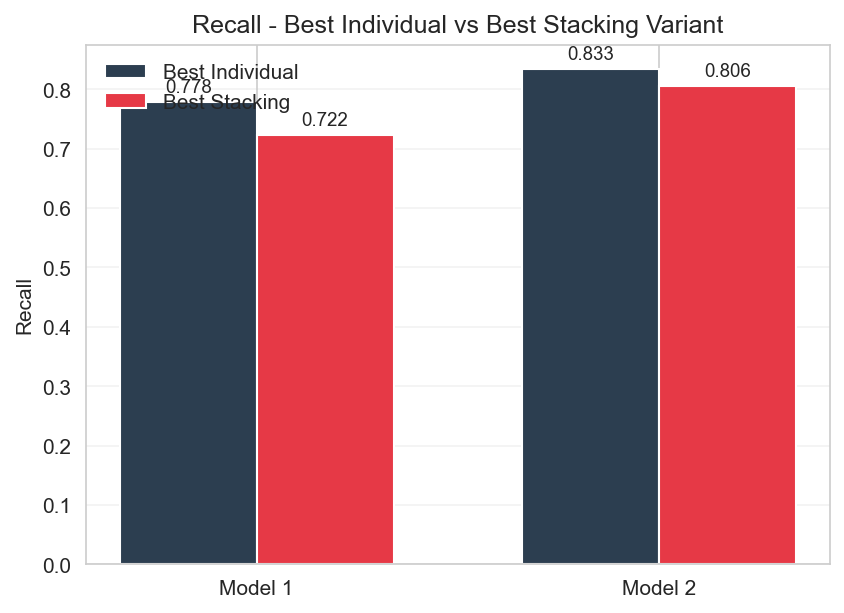

In [72]:
# Plotting the recall-improvement chart is comparing the best individual recall against the best stacking recall for each model set.
fig, ax = plt.subplots(figsize=(6.4, 4.5))
x = np.arange(len(recall_compare))
width = 0.34

individual_bars = ax.bar(
    x - width / 2,
    recall_compare["best_individual_recall"],
    width,
    color=COLORS["neutral"],
    label="Best Individual",
)
stack_colors = [COLORS["improve"] if value >= 0 else COLORS["decline"] for value in recall_compare["absolute_improvement"]]
stack_bars = ax.bar(
    x + width / 2,
    recall_compare["best_stacking_recall"],
    width,
    color=stack_colors,
    label="Best Stacking",
)

ax.set_xticks(x)
ax.set_xticklabels(recall_compare["model_set"])
ax.set_ylabel("Recall")
ax.set_title("Recall - Best Individual vs Best Stacking Variant")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

for bars in [individual_bars, stack_bars]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

output_path = IMAGE_DIR / "14_recall_improvement_stacking.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [73]:
# Writing the recall-improvement insight is explaining whether stacking is helping the project catch more PCOS cases.
recall_markdown = "\n".join([
    "### Recall Improvement Insight",
    "",
    f"- For Model 1, the recall change is **{recall_compare.loc[recall_compare['model_set'] == 'Model 1', 'absolute_improvement'].values[0]:.4f}**.",
    f"- For Model 2, the recall change is **{recall_compare.loc[recall_compare['model_set'] == 'Model 2', 'absolute_improvement'].values[0]:.4f}**.",
    "- Positive values mean stacking improved recall. Negative values mean the best individual model still caught more PCOS cases.",
    "",
    "**Simple meaning:** This chart is showing whether stacking is helping the study miss fewer real PCOS cases.",
])
display(Markdown(recall_markdown))


### Recall Improvement Insight

- For Model 1, the recall change is **-0.0556**.
- For Model 2, the recall change is **-0.0277**.
- Positive values mean stacking improved recall. Negative values mean the best individual model still caught more PCOS cases.

**Simple meaning:** This chart is showing whether stacking is helping the study miss fewer real PCOS cases.

In [74]:
# Printing the AUC-improvement table is showing whether stacking improves the best overall class-separation metric for each model set.
best_individual_auc = (
    master[master["approach"] == "Individual"]
    .sort_values(["model_set", "auc"], ascending=[True, False])
    .groupby("model_set")
    .head(1)
    .reset_index(drop=True)
)
best_stacking_auc = (
    master[master["approach"] == "Stacking"]
    .sort_values(["model_set", "auc"], ascending=[True, False])
    .groupby("model_set")
    .head(1)
    .reset_index(drop=True)
)

auc_compare = pd.DataFrame({
    "model_set": best_individual_auc["model_set"],
    "best_individual_model": best_individual_auc["model"].values,
    "best_individual_auc": best_individual_auc["auc"].values,
    "best_stacking_model": best_stacking_auc["model"].values,
    "best_stacking_auc": best_stacking_auc["auc"].values,
})
auc_compare["absolute_improvement"] = auc_compare["best_stacking_auc"] - auc_compare["best_individual_auc"]
print(auc_compare.round(4).to_string(index=False))


model_set best_individual_model  best_individual_auc best_stacking_model  best_stacking_auc  absolute_improvement
  Model 1          Model 1 - RF               0.9098  Model 1 - Stack-LR             0.9113                0.0015
  Model 2         Model 2 - XGB               0.9037  Model 2 - Stack-LR             0.9037                0.0000


Saved figure to: c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\ensemble\15_auc_improvement_stacking.png


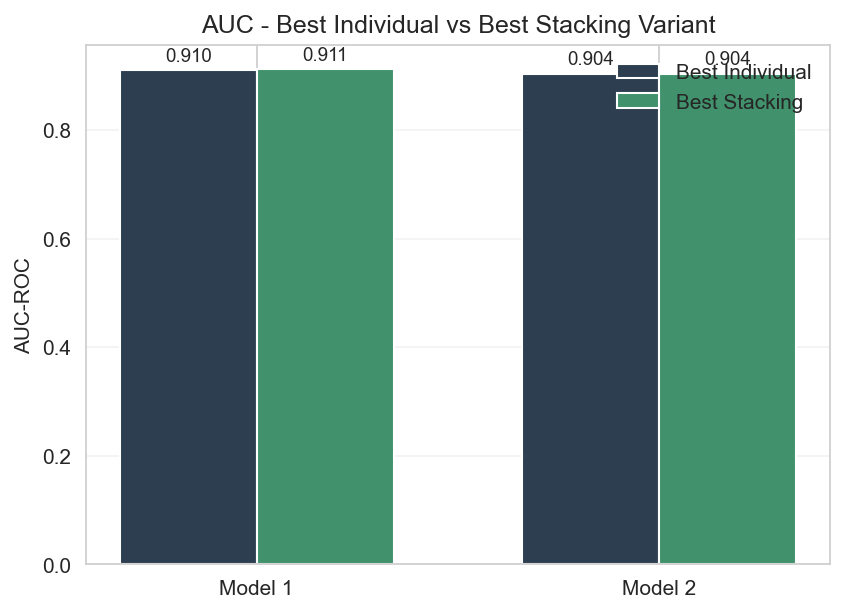

In [75]:
# Plotting the AUC-improvement chart is comparing the strongest individual and strongest stacking result in each model set.
fig, ax = plt.subplots(figsize=(6.4, 4.5))
x = np.arange(len(auc_compare))
width = 0.34

individual_bars = ax.bar(
    x - width / 2,
    auc_compare["best_individual_auc"],
    width,
    color=COLORS["neutral"],
    label="Best Individual",
)
stack_colors = [COLORS["improve"] if value >= 0 else COLORS["decline"] for value in auc_compare["absolute_improvement"]]
stack_bars = ax.bar(
    x + width / 2,
    auc_compare["best_stacking_auc"],
    width,
    color=stack_colors,
    label="Best Stacking",
)

ax.set_xticks(x)
ax.set_xticklabels(auc_compare["model_set"])
ax.set_ylabel("AUC-ROC")
ax.set_title("AUC - Best Individual vs Best Stacking Variant")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

for bars in [individual_bars, stack_bars]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

output_path = IMAGE_DIR / "15_auc_improvement_stacking.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [76]:
# Writing the AUC-improvement insight is explaining whether stacking is improving overall class separation.
auc_markdown = "\n".join([
    "### AUC Improvement Insight",
    "",
    f"- For Model 1, the AUC change is **{auc_compare.loc[auc_compare['model_set'] == 'Model 1', 'absolute_improvement'].values[0]:.4f}**.",
    f"- For Model 2, the AUC change is **{auc_compare.loc[auc_compare['model_set'] == 'Model 2', 'absolute_improvement'].values[0]:.4f}**.",
    "- Positive values mean stacking improved overall separation. Negative values mean the best individual model still separated the classes better.",
    "",
    "**Simple meaning:** This chart is showing whether stacking is making the final prediction boundary clearer than the best single model.",
])
display(Markdown(auc_markdown))


### AUC Improvement Insight

- For Model 1, the AUC change is **0.0015**.
- For Model 2, the AUC change is **0.0000**.
- Positive values mean stacking improved overall separation. Negative values mean the best individual model still separated the classes better.

**Simple meaning:** This chart is showing whether stacking is making the final prediction boundary clearer than the best single model.

In [77]:
# Identifying the best stacking configuration per model set is selecting the variants that move forward to the later optimization notebook.
m1_stacking = master[
    (master["model_set"] == "Model 1") &
    (master["approach"] == "Stacking")
]
m2_stacking = master[
    (master["model_set"] == "Model 2") &
    (master["approach"] == "Stacking")
]

best_m1_stack = m1_stacking.loc[m1_stacking["auc"].idxmax()]
best_m2_stack = m2_stacking.loc[m2_stacking["auc"].idxmax()]

print("Best stacking configuration for Model 1:")
print(best_m1_stack.to_string())
print()
print("Best stacking configuration for Model 2:")
print(best_m2_stack.to_string())
print()
print("These configurations will be carried into the optimization notebook.")


Best stacking configuration for Model 1:
model        Model 1 - Stack-LR
accuracy                 0.8440
precision                0.7879
recall                   0.7222
f1                       0.7536
auc                      0.9113
model_set               Model 1
algorithm              Stack-LR
approach               Stacking

Best stacking configuration for Model 2:
model        Model 2 - Stack-LR
accuracy                 0.8899
precision                0.8529
recall                   0.8056
f1                       0.8286
auc                      0.9037
model_set               Model 2
algorithm              Stack-LR
approach               Stacking

These configurations will be carried into the optimization notebook.


In [78]:
# Writing the key findings section is turning the full stacking comparison into simple thesis-ready result statements.
best_m1_individual = master[
    (master["model_set"] == "Model 1") &
    (master["approach"] == "Individual")
].sort_values("auc", ascending=False).iloc[0]
best_m2_individual = master[
    (master["model_set"] == "Model 2") &
    (master["approach"] == "Individual")
].sort_values("auc", ascending=False).iloc[0]

m1_gap = best_m1_stack["auc"] - best_m1_individual["auc"]
m2_gap = best_m2_stack["auc"] - best_m2_individual["auc"]
cross_model_gap = best_m2_stack["auc"] - best_m1_stack["auc"]
old_cross_model_gap = best_m2_individual["auc"] - best_m1_individual["auc"]

findings_markdown = "\n".join([
    "### Key Findings from Stacking Evaluation",
    "",
    f"For **Model 1**, the best individual model is **{best_m1_individual['model']}** with an AUC of **{best_m1_individual['auc']:.4f}**.",
    f"The best stacking model is **{best_m1_stack['model']}** with an AUC of **{best_m1_stack['auc']:.4f}**.",
    f"This is a change of **{m1_gap:.4f}** AUC points. This is showing whether stacking is helping the non-invasive model combine the base learners better than any single algorithm alone.",
    "",
    f"For **Model 2**, the best individual model is **{best_m2_individual['model']}** with an AUC of **{best_m2_individual['auc']:.4f}**.",
    f"The best stacking model is **{best_m2_stack['model']}** with an AUC of **{best_m2_stack['auc']:.4f}**.",
    f"This is a change of **{m2_gap:.4f}** AUC points. This is showing whether stacking is helping the invasive benchmark use the hormonal and ultrasound signal more effectively.",
    "",
    f"The best meta-learner for Model 1 is **{best_m1_stack['algorithm']}**, while the best meta-learner for Model 2 is **{best_m2_stack['algorithm']}**.",
    "This is revealing which kind of second-level rule is working best for each feature set. If a linear meta-learner wins, the base models only need a simple combination. If a tree-based or boosted meta-learner wins, the best final combination rule is more complex.",
    "",
    f"The AUC gap between the best Model 1 stack and the best Model 2 stack is **{cross_model_gap:.4f}**.",
    f"The earlier best-individual gap was **{old_cross_model_gap:.4f}**.",
    "This is showing whether stacking is closing the non-invasive versus invasive gap or keeping it mostly the same.",
    "",
    "### Simple Summary",
    "",
    "Stacking is now showing whether combining the three base learners is better than trusting the best single learner.",
    "If the gain is small, the individual model was already strong.",
    "If the gain is clear, stacking becomes the better model family to carry into the optimization notebook.",
])
display(Markdown(findings_markdown))


### Key Findings from Stacking Evaluation

For **Model 1**, the best individual model is **Model 1 - RF** with an AUC of **0.9098**.
The best stacking model is **Model 1 - Stack-LR** with an AUC of **0.9113**.
This is a change of **0.0015** AUC points. This is showing whether stacking is helping the non-invasive model combine the base learners better than any single algorithm alone.

For **Model 2**, the best individual model is **Model 2 - XGB** with an AUC of **0.9037**.
The best stacking model is **Model 2 - Stack-LR** with an AUC of **0.9037**.
This is a change of **0.0000** AUC points. This is showing whether stacking is helping the invasive benchmark use the hormonal and ultrasound signal more effectively.

The best meta-learner for Model 1 is **Stack-LR**, while the best meta-learner for Model 2 is **Stack-LR**.
This is revealing which kind of second-level rule is working best for each feature set. If a linear meta-learner wins, the base models only need a simple combination. If a tree-based or boosted meta-learner wins, the best final combination rule is more complex.

The AUC gap between the best Model 1 stack and the best Model 2 stack is **-0.0076**.
The earlier best-individual gap was **-0.0061**.
This is showing whether stacking is closing the non-invasive versus invasive gap or keeping it mostly the same.

### Simple Summary

Stacking is now showing whether combining the three base learners is better than trusting the best single learner.
If the gain is small, the individual model was already strong.
If the gain is clear, stacking becomes the better model family to carry into the optimization notebook.

In [79]:
# Running the final output verification is checking that every required stacking file exists and is not empty.
required_files = [
    MODELS_DIR / "model1_stack_lr_meta.pkl",
    MODELS_DIR / "model1_stack_rf_meta.pkl",
    MODELS_DIR / "model1_stack_xgb_meta.pkl",
    MODELS_DIR / "model1_oof_predictions.npy",
    MODELS_DIR / "model2_stack_lr_meta.pkl",
    MODELS_DIR / "model2_stack_rf_meta.pkl",
    MODELS_DIR / "model2_stack_xgb_meta.pkl",
    MODELS_DIR / "model2_oof_predictions.npy",
    DATA_DIR / "stacking_results.csv",
    DATA_DIR / "master_results_all_models.csv",
    IMAGE_DIR / "01_model1_oof_prediction_distributions.png",
    IMAGE_DIR / "02_model2_oof_prediction_distributions.png",
    IMAGE_DIR / "03_model1_stack_lr_confusion_matrix.png",
    IMAGE_DIR / "04_model1_stack_rf_confusion_matrix.png",
    IMAGE_DIR / "05_model1_stack_xgb_confusion_matrix.png",
    IMAGE_DIR / "06_model2_stack_lr_confusion_matrix.png",
    IMAGE_DIR / "07_model2_stack_rf_confusion_matrix.png",
    IMAGE_DIR / "08_model2_stack_xgb_confusion_matrix.png",
    IMAGE_DIR / "09_model1_stacking_roc_curves.png",
    IMAGE_DIR / "10_model2_stacking_roc_curves.png",
    IMAGE_DIR / "11_model1_individual_vs_stack_comparison.png",
    IMAGE_DIR / "12_model2_individual_vs_stack_comparison.png",
    IMAGE_DIR / "13_master_stacking_heatmap.png",
    IMAGE_DIR / "14_recall_improvement_stacking.png",
    IMAGE_DIR / "15_auc_improvement_stacking.png",
]

all_passed = True
for path in required_files:
    exists = path.exists()
    size_ok = exists and path.stat().st_size > 0
    passed = exists and size_ok
    if not passed:
        all_passed = False
    status = "PASS" if passed else "FAIL"
    size_text = path.stat().st_size if exists else 0
    print(f"[{status}] {path} ({size_text} bytes)")

print()
if all_passed:
    print("All 25 stacking output files verified successfully.")
else:
    print("WARNING: Some stacking output files are missing or empty. Review the cells above.")


[PASS] c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_stack_lr_meta.pkl (911 bytes)
[PASS] c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_stack_rf_meta.pkl (2114089 bytes)
[PASS] c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_stack_xgb_meta.pkl (212951 bytes)
[PASS] c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_oof_predictions.npy (14096 bytes)
[PASS] c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_stack_lr_meta.pkl (911 bytes)
[PASS] c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_stack_rf_meta.pkl (2127529 bytes)
[PASS] c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_stack_xgb_meta.pkl (212938 bytes)
[PASS] c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_oof_predictions.npy (14096 bytes)
[PASS] c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modellin

In [80]:
# Writing the closing summary is documenting what this notebook completed and what the next notebook will do.
closing_markdown = "\n".join([
    "### Notebook Summary and Next Steps",
    "",
    "This notebook has now trained and saved **six stacking models**:",
    "",
    "- `models/model1_stack_lr_meta.pkl`",
    "- `models/model1_stack_rf_meta.pkl`",
    "- `models/model1_stack_xgb_meta.pkl`",
    "- `models/model2_stack_lr_meta.pkl`",
    "- `models/model2_stack_rf_meta.pkl`",
    "- `models/model2_stack_xgb_meta.pkl`",
    "",
    "It has also saved the out-of-fold matrices, the stacking-only results table, the full master results table, and all ensemble figures.",
    "",
    f"The current best stacking configuration for **Model 1** is **{best_m1_stack['model']}** with an AUC of **{best_m1_stack['auc']:.4f}** and a recall of **{best_m1_stack['recall']:.4f}**.",
    f"The current best stacking configuration for **Model 2** is **{best_m2_stack['model']}** with an AUC of **{best_m2_stack['auc']:.4f}** and a recall of **{best_m2_stack['recall']:.4f}**.",
    "",
    "This notebook is also showing whether stacking is really improving on the best individual models or only matching them. That answer becomes the direct starting point for the next step.",
    "",
    "Notebook 10 will apply metaheuristic optimization to the best stacking configuration for each model set. It will tune the hyperparameters using the selected optimizer workflows, compare convergence behavior, and choose the strongest final thesis model for each feature set.",
])
display(Markdown(closing_markdown))


### Notebook Summary and Next Steps

This notebook has now trained and saved **six stacking models**:

- `models/model1_stack_lr_meta.pkl`
- `models/model1_stack_rf_meta.pkl`
- `models/model1_stack_xgb_meta.pkl`
- `models/model2_stack_lr_meta.pkl`
- `models/model2_stack_rf_meta.pkl`
- `models/model2_stack_xgb_meta.pkl`

It has also saved the out-of-fold matrices, the stacking-only results table, the full master results table, and all ensemble figures.

The current best stacking configuration for **Model 1** is **Model 1 - Stack-LR** with an AUC of **0.9113** and a recall of **0.7222**.
The current best stacking configuration for **Model 2** is **Model 2 - Stack-LR** with an AUC of **0.9037** and a recall of **0.8056**.

This notebook is also showing whether stacking is really improving on the best individual models or only matching them. That answer becomes the direct starting point for the next step.

Notebook 10 will apply metaheuristic optimization to the best stacking configuration for each model set. It will tune the hyperparameters using the selected optimizer workflows, compare convergence behavior, and choose the strongest final thesis model for each feature set.